# 03 — Lateral Forces and the Bicycle Model

In notebook 02 we modelled the tire in one direction: forwards and backwards (longitudinal).
That's enough to simulate a car accelerating and braking in a straight line.

But a car also needs to **turn**, and turning requires lateral (sideways) force.
This notebook covers:

1. How lateral force is generated — and why it's fundamentally different from friction on a ramp
2. **Slip angle** — the key input variable for lateral tire force
3. Pacejka applied laterally — same formula, different parameters
4. **Load sensitivity** — why grip doesn't scale linearly with weight
5. The **bicycle model** — a minimal 2-DOF planar equations-of-motion model
6. **Understeer vs oversteer** — what happens when front and rear tires have different grip

By the end you'll be able to simulate a car cornering, watch it understeer or oversteer,
and understand exactly why it does.

In [1]:
import sys
sys.path.insert(0, 'lib')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

from engine  import CAR_MASS
from pacejka import pacejka, pacejka_peak

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
print('Imports OK')

Imports OK


## 1 — Why does a tire generate lateral force?

Intuition first.

When you steer a car, the front wheels rotate to point slightly sideways relative to
the direction the car is actually moving.  At that moment the front of the tire contact
patch is being dragged sideways across the tarmac.  The rubber deforms, grips, and
pushes back — that push is **lateral force**.

This is **not** the same as sliding friction.  The tire is still (mostly) rolling — it's
not skidding sideways.  The lateral force comes from **elastic shear deformation** of the
rubber in the contact patch.  The tire tread elements enter the contact patch pointing
in the direction of travel, get dragged sideways as they roll through, then spring back
when they leave.  The accumulated shear stress is what creates the force.

This is why race engineers care so much about **tire construction and compound** — the
elastic properties of the rubber determine how much lateral force you get per degree of
slip.  A softer compound deforms more, loads earlier, but heats up faster.

---

### The key variable: slip angle α

The input that determines how much lateral force a tire generates is the **slip angle** (α),
defined as the angle between the direction the tire is *pointing* and the direction it is
*actually moving* (its velocity vector).

| Symbol | Meaning | Typical range |
|--------|---------|---------------|
| α | Slip angle (rad) | −0.5 to +0.5 rad (±30°) |
| Fy | Lateral force (N) | −8000 to +8000 N per axle |
| Fz | Normal load (N) | 1500–5000 N per tire |
| δ | Steer angle (rad) | −0.15 to +0.15 rad |
| ψ̇ | Yaw rate (rad/s) | −2 to +2 rad/s |
| Vx | Longitudinal velocity (m/s) | 5–100 m/s |
| Vy | Lateral velocity (m/s) | −5 to +5 m/s |
| a | CG-to-front-axle distance (m) | 1.94 m (F1) |
| b | CG-to-rear-axle distance (m) | 1.66 m (F1) |

Convention used here (ISO vehicle axes):
- **x** = forward
- **y** = left
- **z** = up
- Positive steer = turning left → positive α_front → positive Fy_front (force pushes nose left)

The slip angle formulas for the front and rear axles of a bicycle model are:

$$\alpha_f = \delta - \arctan\!\left(\frac{V_y + a\,\dot\psi}{V_x}\right)$$

$$\alpha_r = -\arctan\!\left(\frac{V_y - b\,\dot\psi}{V_x}\right)$$

**Intuition for α_f:**
- `arctan(Vy + a·ψ̇) / Vx` is the angle of the front axle's velocity vector relative to the car's heading
- We subtract that from the steer angle δ to get the angle between tire pointing direction and tire velocity direction
- The `a·ψ̇` term accounts for the front of the car swinging sideways as the car yaws

**Intuition for α_r:**
- The rear has no steer angle (δ = 0)
- The `−b·ψ̇` term: when the car yaws, the rear swings in the *opposite* direction to the front

## 2 — Slip angle visualisation

Three situations: no slip, small slip (normal cornering), large slip (limit/oversteer).

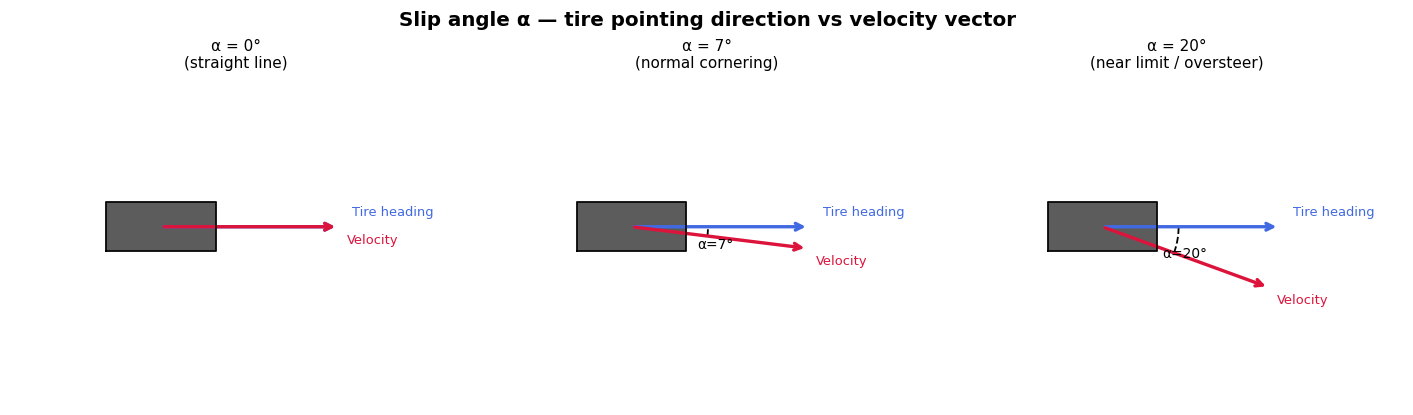

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Slip angle α — tire pointing direction vs velocity vector', fontsize=13, fontweight='bold')

scenarios = [
    (0.0,   'α = 0°\n(straight line)'),
    (7.0,   'α = 7°\n(normal cornering)'),
    (20.0,  'α = 20°\n(near limit / oversteer)'),
]

for ax, (alpha_deg, title) in zip(axes, scenarios):
    alpha = np.radians(alpha_deg)

    # Tire footprint (rectangle centred at origin)
    tw, tl = 0.18, 0.40  # tire width, length in plot units
    rect_corners = np.array([
        [-tl/2, -tw/2], [tl/2, -tw/2], [tl/2, tw/2], [-tl/2, tw/2], [-tl/2, -tw/2]
    ])
    ax.fill(rect_corners[:,0], rect_corners[:,1], color='#333333', alpha=0.8, zorder=3)
    ax.plot(rect_corners[:,0], rect_corners[:,1], 'k-', lw=1, zorder=4)

    # Tire heading arrow (tire points in +x direction by convention)
    ax.annotate('', xy=(0.65, 0), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='royalblue', lw=2.2))
    ax.text(0.70, 0.04, 'Tire heading', color='royalblue', fontsize=8.5)

    # Velocity vector (rotated by slip angle, pointing down-left to show it)
    vx = np.cos(-alpha) * 0.65
    vy = np.sin(-alpha) * 0.65
    ax.annotate('', xy=(vx, vy), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='crimson', lw=2.2))
    ax.text(vx + 0.03, vy - 0.06, 'Velocity', color='crimson', fontsize=8.5)

    # Arc showing slip angle
    if alpha > 0:
        arc_theta = np.linspace(-alpha, 0, 60)
        r = 0.28
        ax.plot(r * np.cos(arc_theta), r * np.sin(arc_theta), 'k--', lw=1.2)
        mid = -alpha / 2
        ax.text(r*1.1*np.cos(mid), r*1.1*np.sin(mid) - 0.06,
                f'α={alpha_deg:.0f}°', fontsize=9, ha='center')

    ax.set_xlim(-0.55, 1.1)
    ax.set_ylim(-0.65, 0.55)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 3 — Lateral Pacejka: same formula, different parameters

The lateral tire force uses the **exact same** Pacejka Magic Formula as longitudinal:

$$F_y = F_z \cdot D \cdot \sin\!\Big(C \cdot \arctan\!\big(B\alpha - E(B\alpha - \arctan(B\alpha))\big)\Big)$$

The difference is **what we plug in** (slip angle α in radians instead of slip ratio)
and the **parameter values**:

| Parameter | Longitudinal | Lateral | Effect |
|-----------|-------------|---------|--------|
| B | 12 | 10 | Lateral curve has slightly lower stiffness |
| C | 1.65 | **1.9** | Wider peak — lateral force holds up longer before falling |
| D | 1.6 | **1.6** | Same peak μ (same compound, same normal load) |
| E | 0.97 | 0.97 | Same curvature |

The higher C (1.9 vs 1.65) means the lateral curve has a **flatter, wider peak** — the tire
keeps generating near-peak lateral force over a broader range of slip angles.  This is why
cornering feels more progressive than braking/traction.

For lateral Pacejka with input in **radians**, B=10 gives the peak near α ≈ 0.25 rad ≈ 14°.
Real F1 tires peak around 3–6° (0.05–0.10 rad) — B would be much higher (~30–50).
We use B=10 for visual clarity so the curves are easy to see on a plot.

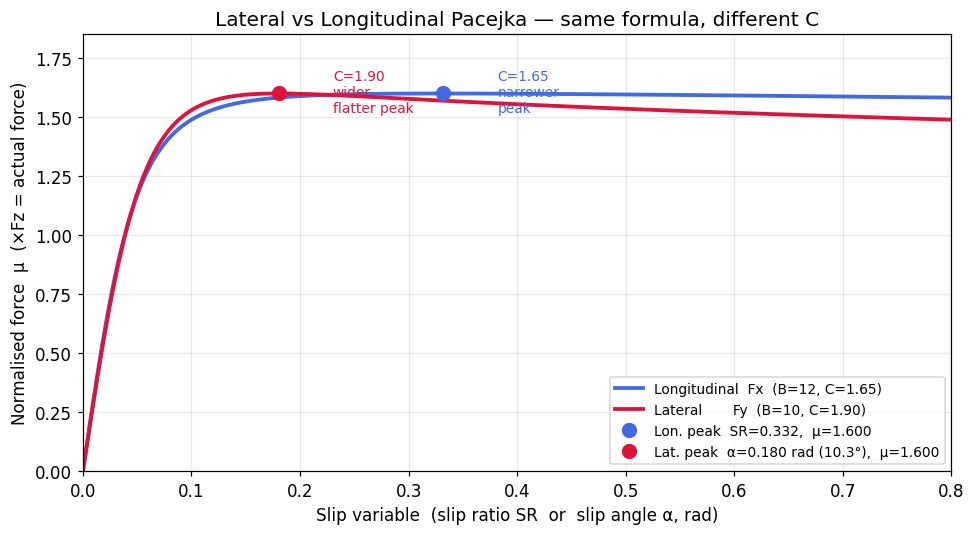

Longitudinal peak:  SR = 0.3317,  μ = 1.6000
Lateral peak:       α  = 0.1802 rad  (10.32°),  μ = 1.6000


In [3]:
# ── Pacejka parameters ────────────────────────────────────────────────────────
B_lon, C_lon, D_lon, E_lon = 12,  1.65, 1.6, 0.97   # longitudinal (vs slip ratio)
B_lat, C_lat, D_lat, E_lat = 10,  1.90, 1.6, 0.97   # lateral (vs slip angle, radians)

sr   = np.linspace(0, 0.8, 500)        # slip ratio  range  (unitless)
sa   = np.linspace(0, 0.8, 500)        # slip angle  range  (radians, ~0–46°)

Fx_n = pacejka(sr, B_lon, C_lon, D_lon, E_lon)   # normalised longitudinal
Fy_n = pacejka(sa, B_lat, C_lat, D_lat, E_lat)   # normalised lateral

sr_pk, Fx_pk = pacejka_peak(B_lon, C_lon, D_lon, E_lon)
sa_pk, Fy_pk = pacejka_peak(B_lat, C_lat, D_lat, E_lat)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(sr, Fx_n, color='royalblue', lw=2.5, label='Longitudinal  Fx  (B=12, C=1.65)')
ax.plot(sa, Fy_n, color='crimson',   lw=2.5, label='Lateral       Fy  (B=10, C=1.90)')

ax.plot(sr_pk, Fx_pk, 'o', color='royalblue', ms=9,
        label=f'Lon. peak  SR={sr_pk:.3f},  μ={Fx_pk:.3f}')
ax.plot(sa_pk, Fy_pk, 'o', color='crimson',   ms=9,
        label=f'Lat. peak  α={sa_pk:.3f} rad ({np.degrees(sa_pk):.1f}°),  μ={Fy_pk:.3f}')

# Annotate the C-value difference
ax.annotate('C=1.65\nnarrower\npeak', xy=(sr_pk+0.05, Fx_pk-0.08),
            fontsize=9, color='royalblue', ha='left')
ax.annotate('C=1.90\nwider,\nflatter peak', xy=(sa_pk+0.05, Fy_pk-0.08),
            fontsize=9, color='crimson', ha='left')

ax.set_xlabel('Slip variable  (slip ratio SR  or  slip angle α, rad)')
ax.set_ylabel('Normalised force  μ  (×Fz = actual force)')
ax.set_title('Lateral vs Longitudinal Pacejka — same formula, different C')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 0.8)
ax.set_ylim(0, 1.85)
plt.tight_layout()
plt.show()

print(f'Longitudinal peak:  SR = {sr_pk:.4f},  μ = {Fx_pk:.4f}')
print(f'Lateral peak:       α  = {sa_pk:.4f} rad  ({np.degrees(sa_pk):.2f}°),  μ = {Fy_pk:.4f}')

## 4 — Load sensitivity: more weight ≠ proportionally more grip

This is one of the most important and counter-intuitive facts in vehicle dynamics.

If you double the normal load on a tire (e.g. via aerodynamic downforce), you get
**less than double** the lateral force.  The D parameter scales **sublinearly** with Fz:

$$D(F_z) = d_1 \cdot F_z - d_2 \cdot F_z^2$$

This is called a **parabolic D model** (sometimes written as $\mu_{peak}(F_z) = d_1 - d_2 \cdot F_z$,
where the effective friction coefficient *decreases* as normal load increases).

**Why this matters for F1:**
- An F1 car at 200 km/h generates ~2× its weight in downforce
- At 300 km/h the car is pressed onto the track with ~3× its weight
- But the tire grip only increases by maybe 1.6–1.8×
- This means the **limit of cornering** doesn't scale as fast as downforce
- It also means weight transfer *always hurts* — a stiffer suspension that reduces dynamic
  load transfer keeps both tires closer to their optimal Fz and maximises total grip

**Why this connects to notebook 05 (weight transfer):**
- When you corner, weight transfers from the inside tires to the outside tires
- The outside tires gain load, but their grip gain is *less* than the grip lost by the inside tires
- Net result: total lateral force from the axle **decreases** under weight transfer
- This is the core reason cars have roll stiffness tuning (sway bars / ARBs)

C:\Users\bbrek\AppData\Local\Temp\ipykernel_1984\744015388.py:43: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


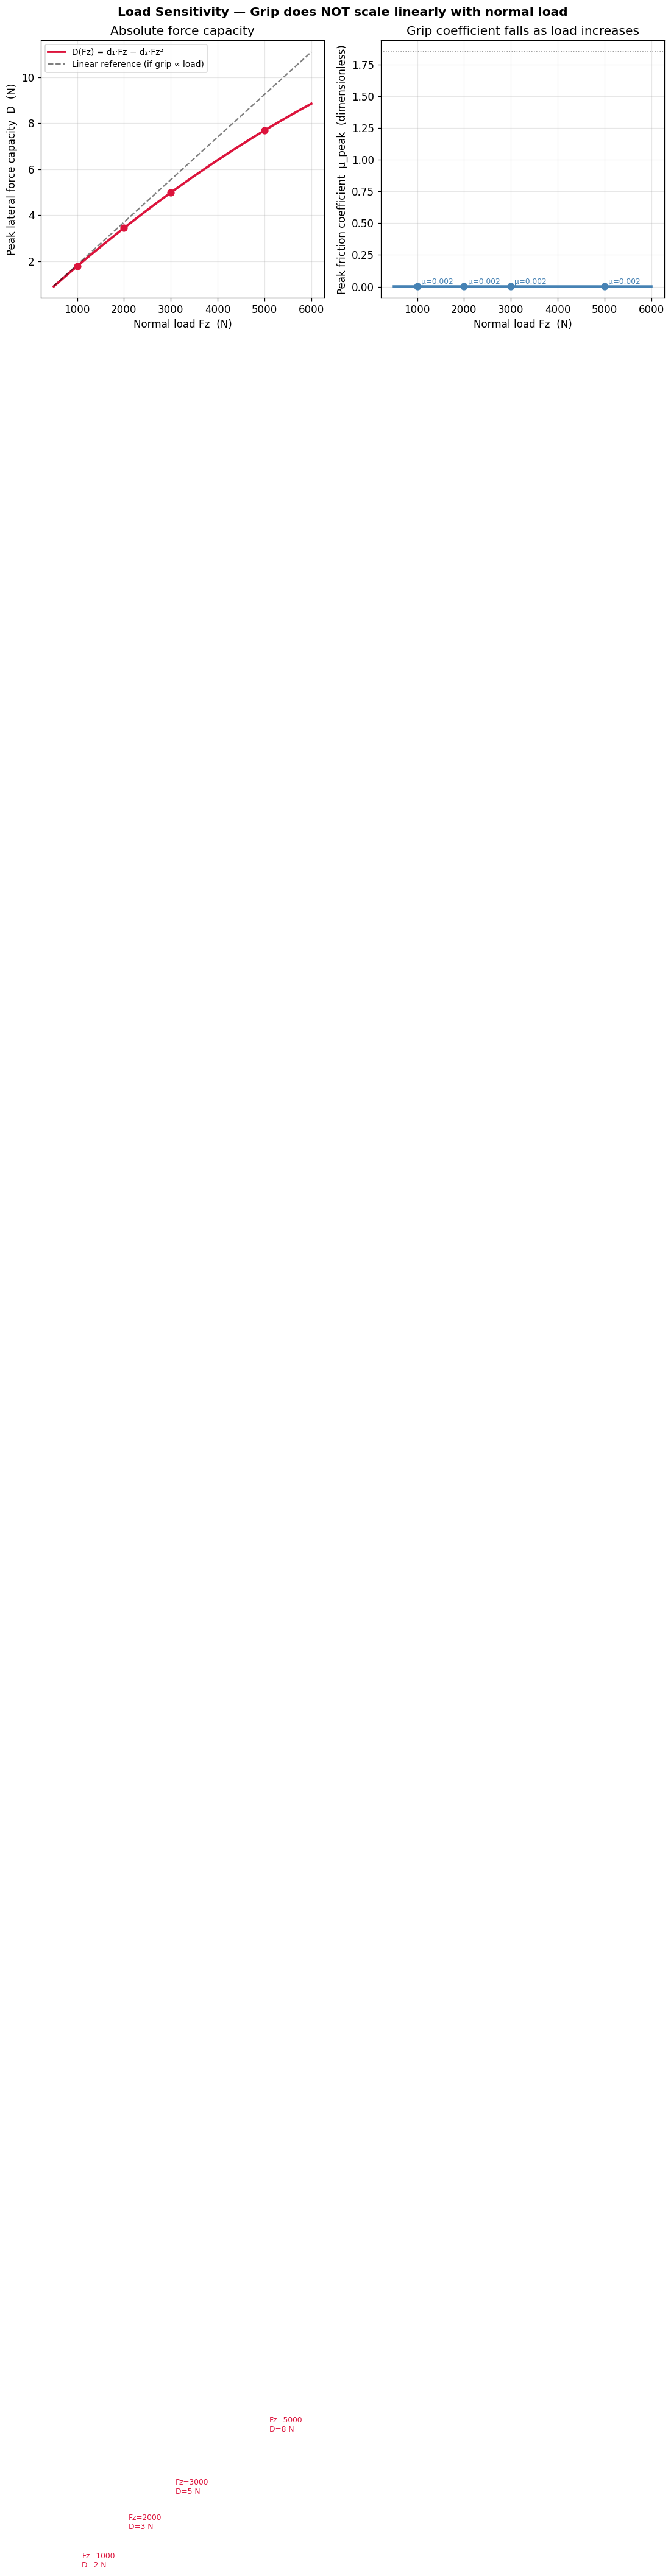

Load sensitivity demo:
  Fz = 1000 N  →  D = 2 N  (μ = 0.002)
  Fz = 2000 N  →  D = 3 N  (μ = 0.002)
  Doubling load multiplied force by 1.93×  (not 2.0×)


In [4]:
# Parabolic D model: D(Fz) = d1*Fz - d2*Fz²
# Calibrated so peak μ = 1.6 at Fz = 2000 N (typical single-tire load without downforce)
# and falls to μ ≈ 1.35 at Fz = 5000 N (high downforce condition)
d1 =  1.85e-3    # N⁻¹  (grip-per-Newton at low load)
d2 =  6.25e-8    # N⁻²  (load-sensitivity coefficient)

Fz_range = np.linspace(500, 6000, 400)
mu_peak  = d1 - d2 * Fz_range           # effective peak μ (decreases with load)
D_range  = d1 * Fz_range - d2 * Fz_range**2   # absolute D value (N)

# Specific reference points
ref_loads = [1000, 2000, 3000, 5000]
ref_D     = [d1*f - d2*f**2 for f in ref_loads]
ref_mu    = [d1   - d2*f    for f in ref_loads]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Load Sensitivity — Grip does NOT scale linearly with normal load', fontweight='bold')

# Left: D(Fz) — absolute force capacity
ax1.plot(Fz_range, D_range, 'crimson', lw=2.5, label='D(Fz) = d₁·Fz − d₂·Fz²')
ax1.plot(Fz_range, d1 * Fz_range, 'k--', lw=1.5, alpha=0.5, label='Linear reference (if grip ∝ load)')
for f, d in zip(ref_loads, ref_D):
    ax1.plot(f, d, 'o', color='crimson', ms=7)
    ax1.annotate(f'Fz={f}\nD={d:.0f} N', xy=(f, d), xytext=(f+100, d-100),
                 fontsize=8, color='crimson')
ax1.set_xlabel('Normal load Fz  (N)')
ax1.set_ylabel('Peak lateral force capacity  D  (N)')
ax1.set_title('Absolute force capacity')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Right: μ(Fz) — normalised grip coefficient falls with load
ax2.plot(Fz_range, mu_peak, 'steelblue', lw=2.5)
for f, m in zip(ref_loads, ref_mu):
    ax2.plot(f, m, 'o', color='steelblue', ms=7)
    ax2.annotate(f'μ={m:.3f}', xy=(f, m), xytext=(f+80, m+0.02), fontsize=8, color='steelblue')
ax2.axhline(d1*1000 - d2*1000**2 / 1000, color='gray', lw=1, ls=':')
ax2.set_xlabel('Normal load Fz  (N)')
ax2.set_ylabel('Peak friction coefficient  μ_peak  (dimensionless)')
ax2.set_title('Grip coefficient falls as load increases')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Load sensitivity demo:')
print(f'  Fz = 1000 N  →  D = {d1*1000 - d2*1000**2:.0f} N  (μ = {d1 - d2*1000:.3f})')
print(f'  Fz = 2000 N  →  D = {d1*2000 - d2*2000**2:.0f} N  (μ = {d1 - d2*2000:.3f})')
print(f'  Doubling load multiplied force by {(d1*2000-d2*2000**2)/(d1*1000-d2*1000**2):.2f}×  (not 2.0×)')

## 5 — The Bicycle Model: equations of motion

The **linear bicycle model** is the simplest model that captures real cornering behaviour.
It merges both left and right tires into one per axle (hence 'bicycle'), and
treats the car as a rigid body moving in the 2D horizontal plane.

**Degrees of freedom:**
- Vy — lateral velocity at the CG  (m/s, positive = moving left)
- ψ̇ — yaw rate  (rad/s, positive = turning left)

The car's position (x, y) and heading ψ are integrated from these.

**Equations of motion:**

Lateral (Newton's 2nd law, y-direction, rotating reference frame):
$$m \left(\dot{V}_y + V_x \dot{\psi}\right) = F_{y,f} + F_{y,r}$$

Yaw (rotational Newton's 2nd law about the CG):
$$I_z \ddot{\psi} = a \cdot F_{y,f} - b \cdot F_{y,r}$$

The **centripetal term** `Vx · ψ̇` appears because we're working in the car's
rotating body frame — the car frame itself is spinning, which adds an apparent
lateral acceleration even if Vy isn't changing.

**Parameters for F1 (2024 rules):**

| Symbol | Value | Notes |
|--------|-------|-------|
| m | 798 kg | minimum car + driver |
| a | 1.94 m | CG to front axle  (46% front weight distribution) |
| b | 1.66 m | CG to rear axle   (54% rear weight distribution) |
| Iz | 450 kg·m² | yaw moment of inertia — very low for F1 |
| L = a+b | 3.60 m | wheelbase |
| Fz_f | ~3600 N | static normal force per front axle |
| Fz_r | ~4200 N | static normal force per rear axle |

The low Iz (450 vs ~2000 for a road car) means an F1 car responds to yaw
inputs very quickly — the steering feels razor-sharp and the car rotates fast.
This is partly due to the compact, low-mass layout and partly by design.

In [5]:
class BicycleModel:
    """
    Non-linear bicycle model with Pacejka lateral tires.

    State vector: [Vx, Vy, psi, psi_dot, x, y]
      Vx      — longitudinal velocity (m/s)  — held constant (no drive/brake here)
      Vy      — lateral velocity (m/s)
      psi     — heading angle (rad)
      psi_dot — yaw rate (rad/s)
      x, y    — world-frame position (m)

    The tire model is the full Pacejka formula (non-linear), so the
    simulation naturally captures the limit of grip and the oversteer
    instability beyond it.
    """

    # F1 vehicle parameters
    M   = 798.0    # kg
    IZ  = 450.0    # kg·m²
    A   = 1.94     # m  (CG to front axle)
    B   = 1.66     # m  (CG to rear axle)
    FZ_F = 798 * 9.81 * 0.46   # N, static front axle load
    FZ_R = 798 * 9.81 * 0.54   # N, static rear axle load

    # Shared Pacejka shape parameters (B, E same for front and rear)
    B_PAC = 10.0
    C_PAC = 1.90
    E_PAC = 0.97

    def __init__(self, Vx=30.0, D_front=1.6, D_rear=1.6):
        """
        Parameters
        ----------
        Vx      : float   Constant forward speed (m/s)
        D_front : float   Pacejka D for front tires (peak normalised lateral force)
        D_rear  : float   Pacejka D for rear tires
                          D_front < D_rear → understeer
                          D_rear  < D_front → oversteer
        """
        self.Vx      = Vx
        self.D_front = D_front
        self.D_rear  = D_rear

        self.Vy      = 0.0
        self.psi     = 0.0
        self.psi_dot = 0.0
        self.x       = 0.0
        self.y       = 0.0
        self.t       = 0.0

        self.history = {
            't':       [], 'x': [], 'y': [],
            'psi':     [], 'psi_dot': [],
            'Vy':      [],
            'alpha_f': [], 'alpha_r': [],
            'Fy_f':    [], 'Fy_r':    [],
            'delta':   [],
        }

    def _slip_angles(self, delta):
        """Compute slip angles for front and rear axles."""
        Vx, Vy, pd = self.Vx, self.Vy, self.psi_dot
        a,  b      = self.A,  self.B

        # Avoid division by zero at very low speed
        if Vx < 0.5:
            return 0.0, 0.0

        alpha_f = delta - np.arctan2(Vy + a * pd, Vx)
        alpha_r =       - np.arctan2(Vy - b * pd, Vx)
        return alpha_f, alpha_r

    def _lateral_force(self, alpha, D, Fz):
        """Pacejka lateral force (N) for one axle."""
        mu = pacejka(alpha, self.B_PAC, self.C_PAC, D, self.E_PAC)
        return mu * Fz

    def step(self, delta, dt=0.005):
        """
        Advance simulation by dt seconds.

        Parameters
        ----------
        delta : float   Steer angle (rad), positive = left
        dt    : float   Timestep (s)
        """
        alpha_f, alpha_r = self._slip_angles(delta)

        Fy_f = self._lateral_force(alpha_f, self.D_front, self.FZ_F)
        Fy_r = self._lateral_force(alpha_r, self.D_rear,  self.FZ_R)

        # Equations of motion
        dVy      = (Fy_f + Fy_r) / self.M - self.Vx * self.psi_dot
        d_psi_dot = (self.A * Fy_f - self.B * Fy_r) / self.IZ

        # Euler integration
        self.Vy      += dVy       * dt
        self.psi_dot += d_psi_dot * dt
        self.psi     += self.psi_dot * dt

        # World-frame position
        speed = np.sqrt(self.Vx**2 + self.Vy**2)
        self.x += speed * np.cos(self.psi) * dt
        self.y += speed * np.sin(self.psi) * dt
        self.t += dt

        self.history['t'].append(self.t)
        self.history['x'].append(self.x)
        self.history['y'].append(self.y)
        self.history['psi'].append(self.psi)
        self.history['psi_dot'].append(self.psi_dot)
        self.history['Vy'].append(self.Vy)
        self.history['alpha_f'].append(np.degrees(alpha_f))
        self.history['alpha_r'].append(np.degrees(alpha_r))
        self.history['Fy_f'].append(Fy_f)
        self.history['Fy_r'].append(Fy_r)
        self.history['delta'].append(np.degrees(delta))

print('BicycleModel defined.')
print(f'  Static Fz_front = {BicycleModel.FZ_F:.0f} N  |  Fz_rear = {BicycleModel.FZ_R:.0f} N')

BicycleModel defined.
  Static Fz_front = 3601 N  |  Fz_rear = 4227 N


## 6 — Understeer vs Oversteer: theory

These two terms describe what happens when a car approaches the **limit of adhesion**.

The key idea: front and rear axles each have a **maximum lateral force** they can generate.
When the demanded force exceeds this, that axle **saturates** — slip angle grows but force stops
increasing (and then falls).

**Which axle saturates first determines the behaviour:**

| Behaviour | Which saturates first | What happens | α_f vs α_r | Driver fix |
|-----------|----------------------|--------------|------------|------------|
| **Understeer** | Front | Car runs wide, nose won't follow steering | α_f > α_r | Reduce steering input, wait for grip |
| **Oversteer** | Rear | Rear steps out, car rotates | α_r > α_f | Counter-steer opposite to spin |
| **Neutral** | Both equally | Car follows steering radius as expected | α_f ≈ α_r | — |

In the model, we control this with the `D` parameter:
- `D_front < D_rear` → front has less grip → **understeer**
- `D_rear < D_front` → rear has less grip → **oversteer**

**F1 context:**
- F1 cars are set up with a **slight understeer bias** at the limit — oversteer at 300 km/h
  is extremely dangerous and difficult to catch
- But the fastest lap times often come from cars on the **edge of oversteer** through
  slow-speed corners where the driver can use rotation to carry more speed
- The **understeer gradient** (K_u) quantifies this: K_u = δ_actual/δ_ackermann − 1
  - K_u > 0 → understeer  (need more steer than pure geometry predicts)
  - K_u < 0 → oversteer   (need less steer, car self-steers)
  - K_u = 0 → neutral steer

## 7 — Neutral steer demo: step steer at constant speed

Setup:
- V = 30 m/s (~108 km/h)
- Steer angle δ = 0 for the first 0.5 s, then step to δ = 0.03 rad (~1.7°) and hold
- D_front = D_rear = 1.6 (equal grip front and rear)

We expect the car to settle into a **steady-state cornering radius** with equal
slip angles front and rear.

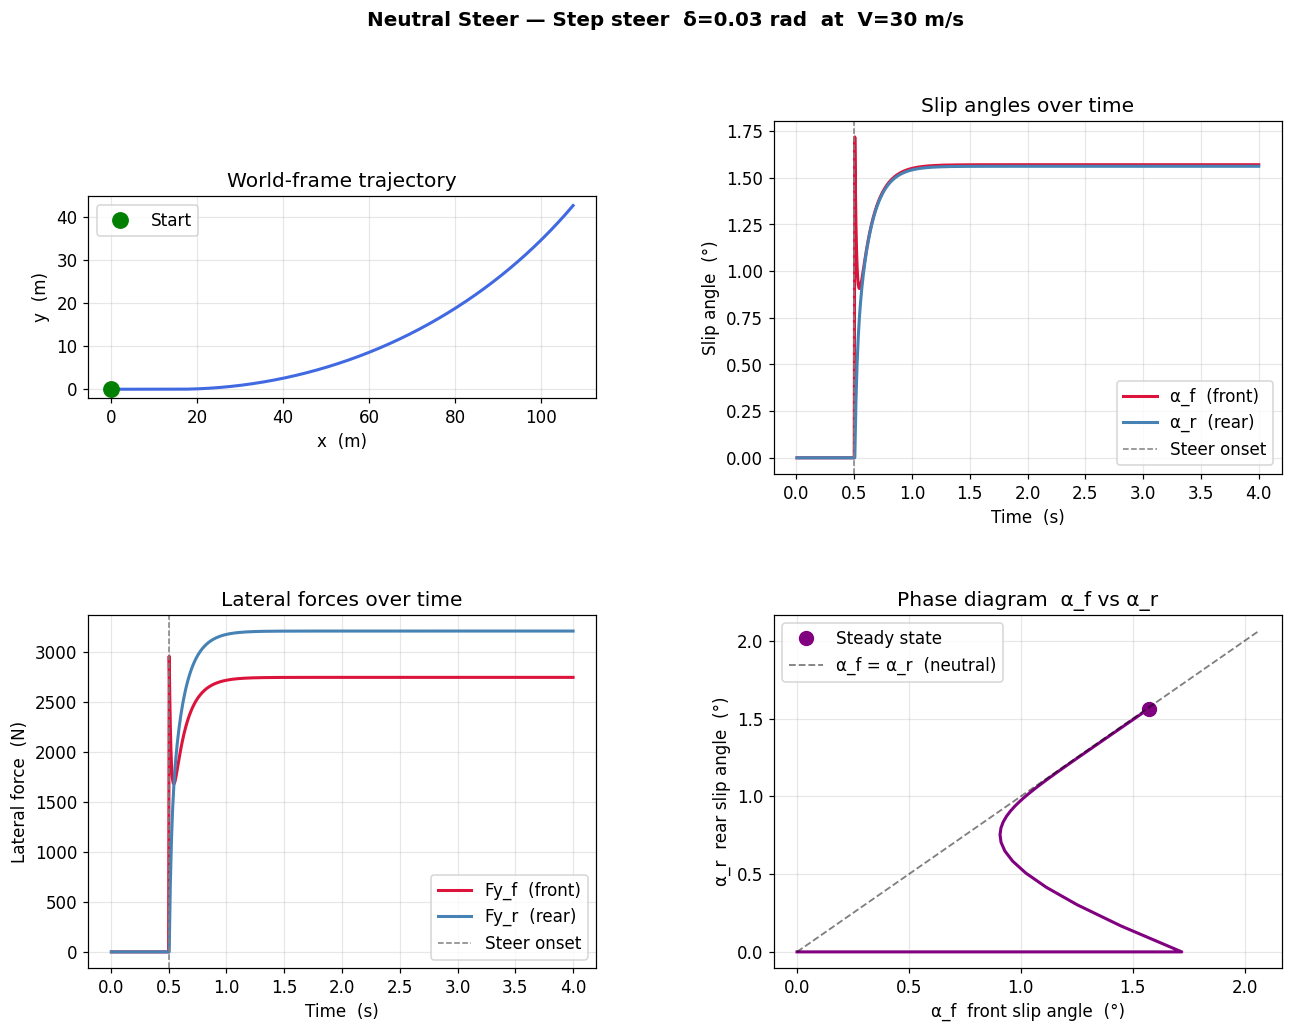

Steady-state front slip angle: 1.570°
Steady-state rear  slip angle: 1.562°
Difference (α_f − α_r):        0.0084°  ← near 0 = neutral


In [6]:
def run_sim(Vx=30.0, D_front=1.6, D_rear=1.6,
            delta_step=0.03, steer_onset=0.5, t_end=4.0, dt=0.005):
    """Run a step-steer manoeuvre and return the BicycleModel instance."""
    car = BicycleModel(Vx=Vx, D_front=D_front, D_rear=D_rear)
    steps = int(t_end / dt)
    for _ in range(steps):
        delta = delta_step if car.t >= steer_onset else 0.0
        car.step(delta, dt)
    return car

neutral = run_sim(D_front=1.6, D_rear=1.6)

h = neutral.history
t = np.array(h['t'])

fig = plt.figure(figsize=(14, 10))
gs  = GridSpec(2, 2, fig, hspace=0.40, wspace=0.35)

fig.suptitle('Neutral Steer — Step steer  δ=0.03 rad  at  V=30 m/s', fontsize=13, fontweight='bold')

# Panel 1: Trajectory
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(h['x'], h['y'], 'royalblue', lw=2)
ax1.plot(h['x'][0], h['y'][0], 'go', ms=10, label='Start')
ax1.set_xlabel('x  (m)')
ax1.set_ylabel('y  (m)')
ax1.set_title('World-frame trajectory')
ax1.set_aspect('equal')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel 2: Slip angles vs time
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(t, h['alpha_f'], 'crimson',   lw=2, label='α_f  (front)')
ax2.plot(t, h['alpha_r'], 'steelblue', lw=2, label='α_r  (rear)')
ax2.axvline(0.5, color='gray', lw=1, ls='--', label='Steer onset')
ax2.set_xlabel('Time  (s)')
ax2.set_ylabel('Slip angle  (°)')
ax2.set_title('Slip angles over time')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Panel 3: Lateral forces vs time
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(t, h['Fy_f'], 'crimson',   lw=2, label='Fy_f  (front)')
ax3.plot(t, h['Fy_r'], 'steelblue', lw=2, label='Fy_r  (rear)')
ax3.axvline(0.5, color='gray', lw=1, ls='--', label='Steer onset')
ax3.set_xlabel('Time  (s)')
ax3.set_ylabel('Lateral force  (N)')
ax3.set_title('Lateral forces over time')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Panel 4: α_f vs α_r phase diagram
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(h['alpha_f'], h['alpha_r'], 'purple', lw=2)
ax4.plot(h['alpha_f'][-1], h['alpha_r'][-1], 'o', color='purple', ms=9, label='Steady state')
# Neutral steer line (α_f = α_r)
lim = max(max(h['alpha_f']), max(h['alpha_r'])) * 1.2
ax4.plot([0, lim], [0, lim], 'k--', lw=1.2, alpha=0.5, label='α_f = α_r  (neutral)')
ax4.set_xlabel('α_f  front slip angle  (°)')
ax4.set_ylabel('α_r  rear slip angle  (°)')
ax4.set_title('Phase diagram  α_f vs α_r')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.show()

ss_af = h['alpha_f'][-1]
ss_ar = h['alpha_r'][-1]
print(f'Steady-state front slip angle: {ss_af:.3f}°')
print(f'Steady-state rear  slip angle: {ss_ar:.3f}°')
print(f'Difference (α_f − α_r):        {ss_af - ss_ar:.4f}°  ← near 0 = neutral')

## 8 — Understeer vs Oversteer comparison

Now we run the same step-steer with three setups:
- **Neutral**:     D_f=1.6, D_r=1.6
- **Understeer**:  D_f=1.0, D_r=1.6  (front has less grip — runs wide)
- **Oversteer**:   D_f=1.6, D_r=1.0  (rear has less grip — will spin)

Watch what happens to the trajectory, and compare α_f vs α_r in steady state.

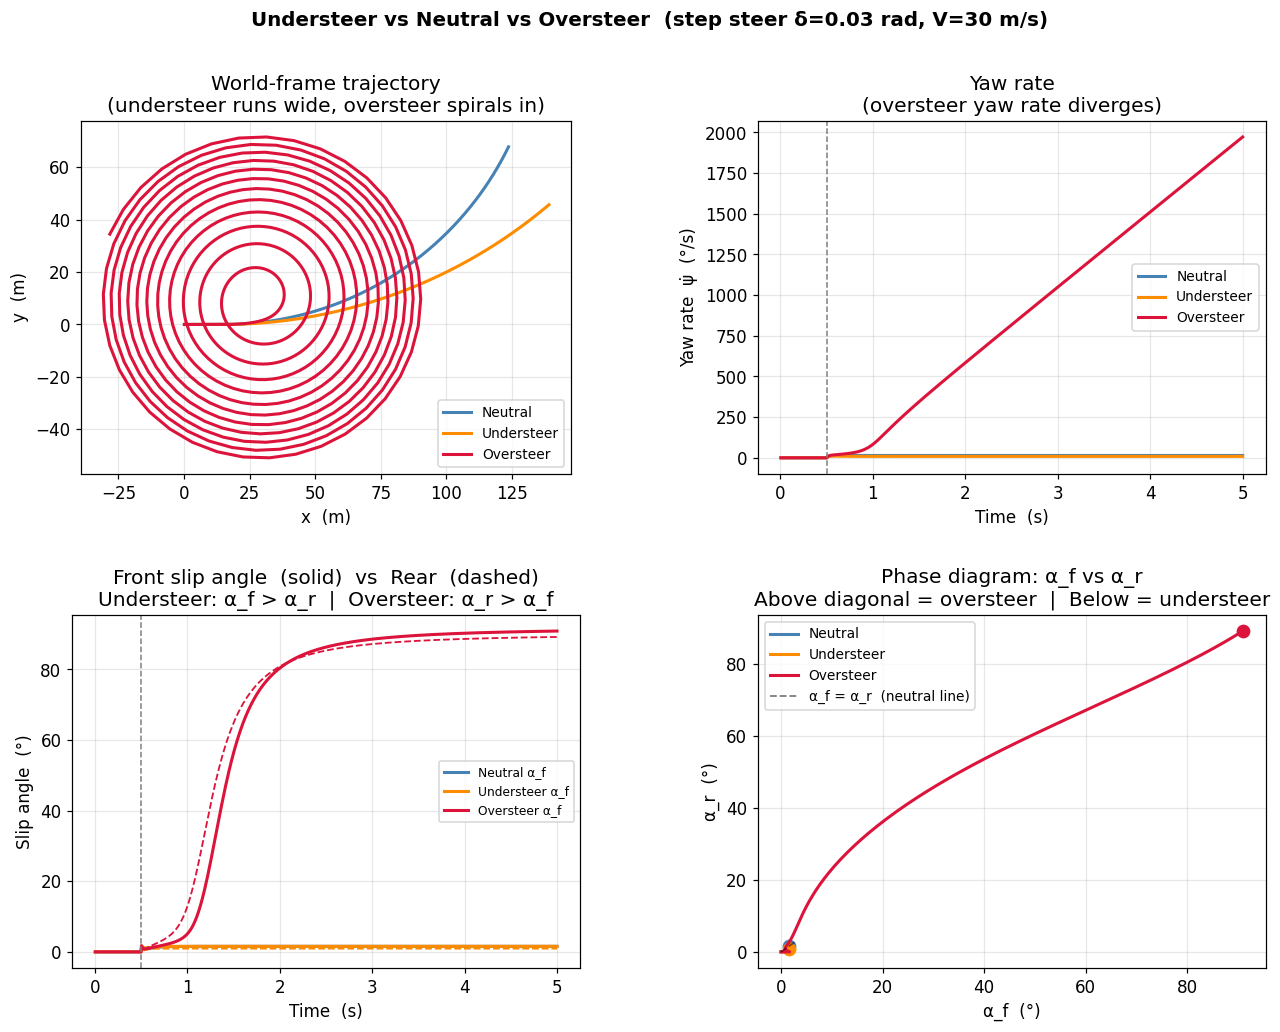

Steady-state slip angles (last timestep):
Setup             α_f (°)    α_r (°)    α_f − α_r Behaviour
------------------------------------------------------------
Neutral             1.570      1.562        0.008   Neutral
Understeer          1.573      0.925        0.648   Understeer
Oversteer          90.890     89.218        1.672   Understeer


In [7]:
setups = [
    {'label': 'Neutral',    'D_f': 1.6, 'D_r': 1.6, 'color': 'steelblue'},
    {'label': 'Understeer', 'D_f': 1.0, 'D_r': 1.6, 'color': 'darkorange'},
    {'label': 'Oversteer',  'D_f': 1.6, 'D_r': 1.0, 'color': 'crimson'},
]

results = {}
for s in setups:
    results[s['label']] = run_sim(D_front=s['D_f'], D_rear=s['D_r'], t_end=5.0)

fig = plt.figure(figsize=(14, 10))
gs  = GridSpec(2, 2, fig, hspace=0.40, wspace=0.35)
fig.suptitle('Understeer vs Neutral vs Oversteer  (step steer δ=0.03 rad, V=30 m/s)',
             fontsize=13, fontweight='bold')

ax1 = fig.add_subplot(gs[0, 0])  # Trajectory
ax2 = fig.add_subplot(gs[0, 1])  # Yaw rate
ax3 = fig.add_subplot(gs[1, 0])  # Slip angles (front)
ax4 = fig.add_subplot(gs[1, 1])  # Phase diagram

for s in setups:
    car   = results[s['label']]
    h     = car.history
    t     = np.array(h['t'])
    color = s['color']
    lbl   = s['label']

    ax1.plot(h['x'], h['y'], color=color, lw=2, label=lbl)

    ax2.plot(t, np.degrees(h['psi_dot']), color=color, lw=2, label=lbl)

    ax3.plot(t, h['alpha_f'], color=color,    lw=2,   label=f'{lbl} α_f')
    ax3.plot(t, h['alpha_r'], color=color,    lw=1.2, ls='--')

    ax4.plot(h['alpha_f'], h['alpha_r'], color=color, lw=2, label=lbl)
    ax4.plot(h['alpha_f'][-1], h['alpha_r'][-1], 'o', color=color, ms=8)

# Trajectory panel
ax1.set_xlabel('x  (m)')
ax1.set_ylabel('y  (m)')
ax1.set_title('World-frame trajectory\n(understeer runs wide, oversteer spirals in)')
ax1.set_aspect('equal')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Yaw rate panel
ax2.axvline(0.5, color='gray', lw=1, ls='--')
ax2.set_xlabel('Time  (s)')
ax2.set_ylabel('Yaw rate  ψ̇  (°/s)')
ax2.set_title('Yaw rate\n(oversteer yaw rate diverges)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# Slip angle panel
ax3.axvline(0.5, color='gray', lw=1, ls='--')
ax3.set_xlabel('Time  (s)')
ax3.set_ylabel('Slip angle  (°)')
ax3.set_title('Front slip angle  (solid)  vs  Rear  (dashed)\nUndersteer: α_f > α_r  |  Oversteer: α_r > α_f')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# Phase diagram
lim = 3.0
ax4.plot([0, lim], [0, lim], 'k--', lw=1.2, alpha=0.5, label='α_f = α_r  (neutral line)')
ax4.set_xlabel('α_f  (°)')
ax4.set_ylabel('α_r  (°)')
ax4.set_title('Phase diagram: α_f vs α_r\nAbove diagonal = oversteer  |  Below = understeer')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

plt.show()

print('Steady-state slip angles (last timestep):')
print(f"{'Setup':<14} {'α_f (°)':>10} {'α_r (°)':>10} {'α_f − α_r':>12} {'Behaviour'}")
print('-' * 60)
for s in setups:
    h   = results[s['label']].history
    af  = h['alpha_f'][-1]
    ar  = h['alpha_r'][-1]
    diff = af - ar
    behaviour = 'Understeer' if diff > 0.05 else ('Oversteer' if diff < -0.05 else 'Neutral')
    print(f"{s['label']:<14} {af:>10.3f} {ar:>10.3f} {diff:>12.3f}   {behaviour}")

## 9 — Summary

**What we built:**

| Component | Key idea |
|-----------|----------|
| Slip angle α | Angle between tire heading and velocity vector — the input to lateral Pacejka |
| Lateral Pacejka | Same formula as longitudinal; C=1.9 gives a wider, flatter peak |
| Load sensitivity | D(Fz) is sublinear — doubling load < doubles grip |
| Bicycle model | 2-DOF planar model: Vy and ψ̇ as states, Fy_f and Fy_r as forcing |
| Understeer | Front saturates first → α_f > α_r → car runs wide |
| Oversteer | Rear saturates first → α_r > α_f → yaw rate diverges / spin |

**What this model is still missing:**

1. **Combined slip** — we modelled lateral and longitudinal forces *separately*; in reality
   the friction circle couples them: hard braking while cornering reduces lateral grip
   → **notebook 04**

2. **Weight transfer** — under cornering the car rolls and load shifts from inside to outside
   tires; combined with load sensitivity this changes balance mid-corner
   → **notebook 05**

3. **Aerodynamics** — downforce increases Fz (and thus grip) speed-dependently
   → **notebook 06**

4. **4-wheel model** — left/right tire loads differ; need to track all 4 individually
   → **notebook 07**

When you're ready, say **done** and we'll move on to notebook 04 — combined slip.